In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#ff7f0e", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    # "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#393b79", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    # "#843c39", # Dark red
    # "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"

color_trainig=colors_sets[9]
color_validation='orange'
color_testing=colors_sets[3]

marker_trainig='s'
marker_validation='*'
marker_testing='o'



size_trainig=30
size_validation=80
size_testing=35

alpha_trainig=0.8
alpha_validation=0.9
alpha_testing=0.4

models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
key_list = models_selected[1:]

heterogeneous_data_type = ['BE', 'ChRad', 'CPn', 'CPp', 'PEn', 'PEp', 'QDB2n', 'QDB2p', 'QDB4n', 'QDB4p', 'MRadN', 'MRadP']
num_properties = 2

In [2]:
models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1'] #Here I am copying all the models with Charge Raidus and Masses

#In the line below we are going to access the data that we have for the binding energies of different models
models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}

filtered_NZ = np.array([models_data_sets[models_selected[0]]['N'].tolist(), models_data_sets[models_selected[0]]['Z'].tolist() ]).T
filtered_NZ

array([[  2,   2],
       [  4,   2],
       [  6,   2],
       ...,
       [156, 108],
       [158, 108],
       [160, 110]])

In [3]:
for model in models:
    print(model, len(models_data_sets[model]["N"]))

ME2 654
MEdelta 654
PC1 654
NL3S 656
SKMS 2459
SKP 2485
SLY4 2479
SV 2484
UNEDF0 2484
UNEDF1 2495


## Necessary Functions

In [4]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train),np.array(validation), np.array(test), np.array(train_list_coordinates),  np.array(validation_list_coordinates),np.array(test_list_coordinates)


In [5]:
def filtered_NZ_extraction(filtered_NZ): #This function will extract isotopes that we want in our analysis

    #We start applying constraints to the above NZ array
    filtered_NZ_new = [] # Create a new list
    for isotope in filtered_NZ:
        if ((isotope[0] >= 8) & (isotope[1] >= 8)) & ( (isotope[0]%2 == 0) & (isotope[1]%2 == 0) ):
            filtered_NZ_new.append(isotope) # Choose the isotope that satisfies the above condition
    filtered_NZ = np.array(filtered_NZ_new) # Turn this into an array
    return filtered_NZ

def unified_NZ(models_data_sets, models_selected, filtered_NZ):
    for model in models_selected: # Loop throught every model
        filtered_NZ_new = [] 
        for isotope in filtered_NZ:
            if ((models_data_sets[model]["N"] == isotope[0]) & (models_data_sets[model]["Z"] == isotope[1])).any():
                filtered_NZ_new.append(isotope) #Choose every isotope that does appears in the model we are considering
        filtered_NZ = np.array(filtered_NZ_new)# Update our list of filtered_NZ and loop through the remaining models.
    #A dataframe containing this NZ inputs
    filtered_NZ_df = {'N' : filtered_NZ.T[0], 'Z': filtered_NZ.T[1]}
    filtered_NZ_df = pd.DataFrame(filtered_NZ_df)

    return filtered_NZ, filtered_NZ_df

def selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, heterogeneous_data_type, num_properties):
    selected_models_data_sets_list = []
    for i in range(num_properties):
        selected_models_data_sets=pd.DataFrame(filtered_NZ_df)

        for model in models_selected:
            a = pd.merge(filtered_NZ_df, pd.DataFrame(models_data_sets[model]), how = 'inner', on  = ['N', 'Z'])
            selected_models_data_sets[model] = a[heterogeneous_data_type[i]]
        selected_models_data_sets.rename(columns={models_selected[0]: 'truth'}, inplace=True)
        selected_models_data_sets_list.append(selected_models_data_sets)
    return selected_models_data_sets_list

def models_output_extraction(selected_models_data_sets, train_coordinates, validation_coordinates, test_coordinates):
    models_output = selected_models_data_sets #This gives the initial values for models output
    
    # We will add a column of mass number and rearrange our dataframe
    models_output["A"] = models_output["N"] + models_output["Z"] 
    cols = list(models_output.columns)
    cols[2], cols[-1] = cols[-1], cols[2]
    models_output = models_output[cols]

    #Next steps is to extract this dataframe at train,validation,test coordinates
    models_output_train = models_output.iloc[train_coordinates]
    models_output_validation = models_output.iloc[validation_coordinates]
    models_output_test = models_output.iloc[test_coordinates]

    return [models_output,models_output_train,models_output_validation,models_output_test]

def filtered_models_output(Selected_element, models_output_list): 
    Z_range=(Selected_element,Selected_element)
    N_range=(0,300)
    models_output, models_output_train, models_output_validation, models_output_test = models_output_list

    
    filtered_models_output = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1]) & 
                         (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1])]  
    
    filtered_models_output_train = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                         (models_output_train['N'] >= N_range[0]) & (models_output_train['N'] <= N_range[1])]
    
    filtered_models_output_test = models_output_test[(models_output_test['Z'] >= Z_range[0]) & (models_output_test['Z'] <= Z_range[1]) & 
                         (models_output_test['N'] >= N_range[0]) & (models_output_test['N'] <= N_range[1])]
    
    filtered_models_output_validation = models_output_validation[(models_output_validation['Z'] >= Z_range[0]) & (models_output_validation['Z'] <= Z_range[1]) & 
                         (models_output_validation['N'] >= N_range[0]) & (models_output_validation['N'] <= N_range[1])]
    
    
    stable_selected_isotope=[]
    
    for i in range(len(stable_coordinates)):
        if stable_coordinates[i][1]==Selected_element:
            stable_selected_isotope.append(stable_coordinates[i])
    
    stable_selected_isotope=np.array(stable_selected_isotope)
    
    # df[df['Column1'].isin(values_array)]
    
    filtered_models_output_stable = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                         (models_output_train['N'].isin(stable_selected_isotope.T[0]))]
    
    return [filtered_models_output,filtered_models_output_train, filtered_models_output_validation, filtered_models_output_test, filtered_models_output_stable]

def models_PC_output(Vt_hat, model_predictions, predictions_mean):
    models_PC = {}

    models_PC["PC_0"] = predictions_mean
    
    for i in range(components_kept):
        models_PC["PC_" + str(i+1)] = np.dot(Vt_hat[i], model_predictions.T)
    
    # models_PC["N"] = models_output["N"]
    # models_PC["Z"] = models_output["Z"]
    # models_PC["A"] = models_PC["N"] + models_PC["Z"]
    
    models_PC = pd.DataFrame(models_PC)

    return models_PC

def rndm_m_mass_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_mass = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_mass= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_mass.append(yvals_rand_mass +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_mass)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_mass),1.0 * samples[i][-2]**2 ) )))  
        
    lower_mass = np.percentile(rndm_m_mass, 2.5, axis = 0)
    median_mass = np.percentile(rndm_m_mass, 50, axis = 0)
    upper_mass = np.percentile(rndm_m_mass, 97.5, axis = 0)

    return [lower_mass, median_mass, upper_mass]

def rndm_m_radius_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_radius = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_radius= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_radius.append(yvals_rand_radius +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_radius)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * samples[i][-1]**2 ) )))  
        
    lower_radius = np.percentile(rndm_m_radius, 2.5, axis = 0)
    median_radius = np.percentile(rndm_m_radius, 50, axis = 0)
    upper_radius = np.percentile(rndm_m_radius, 97.5, axis = 0)

    return [lower_radius, median_radius, upper_radius]

def rndm_m_mass_calculator_coverage(samples, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * samples_rand[i][-1]**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m

def rndm_m_radius_calculator_coverage(samples, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * (samples_rand[i][-1]/50)**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m

def coverage_calculation(rndm_m_full, models_output):
    percentiles = np.arange(0, 101, 5)


    data_total=len(rndm_m_full.T)
    data_true=models_output["truth"].tolist()
    M_evals=len(rndm_m_full)
    
    
    coverage = []
    
    for p in percentiles:
        count_covered = 0
        for i in range(data_total):
            # Sort model evaluations for the i-th data point
            sorted_evals = np.sort(rndm_m_full.T[i])
            
            # Find indices for lower and upper bounds of the credible interval
            lower_idx = int((0.5 - p / 200) * M_evals)
            upper_idx = int((0.5 + p / 200) * M_evals) - 1  # Adjusted to avoid out-of-bounds
            
            # Check if the true value y[i] is within this interval
            if sorted_evals[lower_idx] <= data_true[i] <= sorted_evals[upper_idx]:
                count_covered += 1
                
        # Calculate and store the coverage percentage
        coverage.append(count_covered / data_total * 100)
        
    return coverage


In [6]:
def plot_filtered_supermodel(supermodel_predictions_range, filtered_models_output_list, Z, unit, property, Constraint):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    lower, median, upper = supermodel_predictions_range

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_models_output["N"], -median/filtered_models_output['A'], color="darkkhaki", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    plt.plot(filtered_models_output["N"], -lower/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    plt.plot(filtered_models_output["N"], -upper/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    
    plt.fill_between(filtered_models_output["N"], -lower/filtered_models_output['A'], -upper/filtered_models_output['A'], color="darkkhaki",alpha=0.3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = -filtered_models_output_train['truth']/filtered_models_output_train["A"], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_trainig,color=color_trainig,s=100,marker=marker_trainig,zorder=2)

    ax.scatter(x = filtered_models_output_validation["N"], y = -filtered_models_output_validation['truth']/filtered_models_output_validation["A"], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)
    
    ax.scatter(x = filtered_models_output_test["N"], y = -filtered_models_output_test['truth']/filtered_models_output_test["A"], label = "$\mathcal{X}_0^{te}$", alpha = alpha_testing,color=color_testing,s=100,marker=marker_testing,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y =- filtered_models_output_stable['truth']/filtered_models_output_stable["A"], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}/A$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    # plt.savefig(f'{savefig}')
    plt.show()

In [7]:
stable_coordinates_full=np.loadtxt("Stable-Isotopes.txt")

In [8]:
stable_coordinates=filtered_NZ_extraction(stable_coordinates_full)

In [9]:
filtered_NZ= filtered_NZ_extraction(filtered_NZ) #Extract even even nuclei with N, Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ(models_data_sets, models_selected, filtered_NZ) #Choose nuclei that appears in every models of interest

In [10]:
Full_set=np.copy(filtered_NZ)

In [11]:
#Traditional way with stable coordinates

distance1=2
distance2=3

training_set, validation_set, test_set,train_coordinates, validation_coordinates,test_coordinates=separate_points_distance_allSets(Full_set, stable_coordinates, distance1,distance2)

In [12]:
# Extracting 2 data frames that contains predictions of different properties of nuclei
selected_models_data_sets_mass, selected_models_data_sets_radius = selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, \
                                                                                                        heterogeneous_data_type, num_properties)

In [13]:
#Extract models output of different categories (mass and radius) and classify them into 4 regions: all,train, validation, test
models_output_mass_list = models_output_extraction(selected_models_data_sets_mass, train_coordinates, validation_coordinates, test_coordinates)
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates, validation_coordinates, test_coordinates)

#Separate them for further use
[models_output_mass, models_output_mass_train, models_output_mass_validation, models_output_mass_test] = models_output_mass_list
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

In [14]:
filtered_models_output_mass_list = filtered_models_output(50, models_output_mass_list)
filtered_models_output_radius_list = filtered_models_output(50, models_output_radius_list)

In [15]:
filtered_models_output_mass = filtered_models_output_mass_list[0]
filtered_models_output_mass_train = filtered_models_output_mass_list[1]
filtered_models_output_mass_validation = filtered_models_output_mass_list[2]
filtered_models_output_mass_test = filtered_models_output_mass_list[3]
filtered_models_output_mass_stable = filtered_models_output_mass_list[4]

filtered_models_output_radius = filtered_models_output_radius_list[0]
filtered_models_output_radius_train = filtered_models_output_radius_list[1]
filtered_models_output_radius_validation = filtered_models_output_radius_list[2]
filtered_models_output_radius_test = filtered_models_output_radius_list[3]
filtered_models_output_radius_stable = filtered_models_output_radius_list[4]

model_predictions_mass=models_output_mass[key_list].values
model_predictions_mass_train=models_output_mass_train[key_list].values
model_predictions_mass_validation=models_output_mass_validation[key_list].values
model_predictions_mass_test=models_output_mass_test[key_list].values

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values

model_predictions_combined = np.vstack((model_predictions_mass, model_predictions_radius))
model_predictions_combined_train = np.vstack((model_predictions_mass_train, model_predictions_radius_train))
model_predictions_combined_validation = np.vstack((model_predictions_mass_validation, model_predictions_radius_validation))
model_predictions_combined_test = np.vstack((model_predictions_mass_test, model_predictions_radius_test))

predictions_mean_mass= np.mean(model_predictions_mass, axis=1)
predictions_mean_mass_train= np.mean(model_predictions_mass_train, axis=1)
predictions_mean_mass_validation= np.mean(model_predictions_mass_validation, axis=1)
predictions_mean_mass_test= np.mean(model_predictions_mass_test, axis=1)

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_combined= np.mean(model_predictions_combined, axis=1)
predictions_mean_combined_train= np.mean(model_predictions_combined_train, axis=1)
predictions_mean_combined_validation= np.mean(model_predictions_combined_validation, axis=1)
predictions_mean_combined_test= np.mean(model_predictions_combined_test, axis=1)

In [16]:
centering_data = True

if centering_data:
    model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,None]
    model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train.reshape(300,1)
    model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,np.newaxis]

if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train.reshape(300,1)
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,np.newaxis]

if centering_data:
    model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, None]
    model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train.reshape(600,1)
    model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, np.newaxis]

In [17]:
model_predictions_mass_train_processed

array([[ 1.47288344, -0.09811656,  0.56088344, ..., -0.18488056,
        -0.84462156, -5.84765656],
       [-0.14384044, -0.71284044, -0.42084044, ..., -0.17229444,
        -0.09549844, -6.01265944],
       [-1.28766944, -0.86566944, -0.64866944, ..., -0.33433644,
         0.04040256, -6.46042744],
       ...,
       [ 0.94840611,  4.11340611,  2.49140611, ..., -1.16109189,
         3.16024811,  2.42447411],
       [ 1.07389989,  4.19789989,  5.12689989, ..., -1.60015811,
         2.92331889,  3.39106089],
       [ 1.177221  ,  4.133221  ,  4.086221  , ..., -1.438176  ,
         3.095105  ,  3.025144  ]])

### PCA

In [18]:
U, S, Vt = np.linalg.svd(model_predictions_mass_train_processed)

In [19]:
key_list

['MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1']

[9.95644377e+01 3.91824570e+01 2.98160750e+01 2.51885143e+01
 1.80567344e+01 1.72322067e+01 9.59782302e+00 4.88937342e+00
 5.11579461e-12]


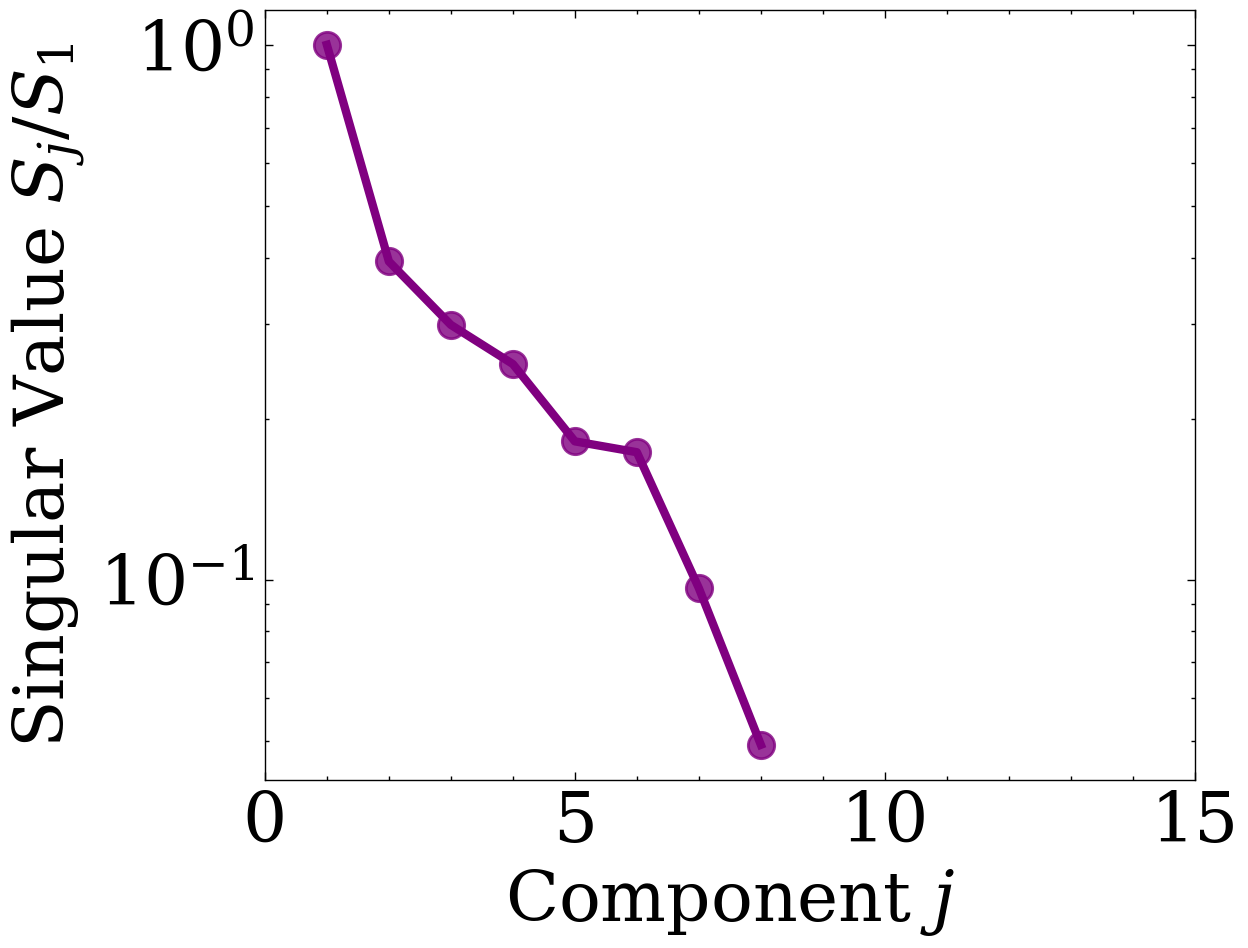

In [20]:
print(S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,5,10,15])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.show()

In [21]:
components_kept = 4

In [22]:
U_hat = np.array([U.T[i] for i in range(components_kept)]).T

S_hat = S[:components_kept]

Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])

### We will now continue to perfrom our analysis with PCA

In [23]:
models_PC_mass = models_PC_output(Vt_hat, model_predictions_mass, predictions_mean_mass)
models_PC_mass_train = models_PC_output(Vt_hat, model_predictions_mass_train, predictions_mean_mass_train)
models_PC_mass_validation = models_PC_output(Vt_hat, model_predictions_mass_validation, predictions_mean_mass_validation)
models_PC_mass_test = models_PC_output(Vt_hat, model_predictions_mass_test, predictions_mean_mass_test)

In [24]:
models_PC_mass_train

,PC_0,PC_1,PC_2,PC_3,PC_4
0,127.553117,0.035056,0.030686,-0.099093,-0.109694
1,142.135840,0.054499,-0.011049,-0.075946,-0.089781
2,154.080669,0.068915,-0.042342,-0.095890,-0.063379
3,134.813314,0.057407,-0.028486,-0.042996,-0.061095
4,157.504325,0.048838,-0.021268,-0.041323,-0.079512
...,...,...,...,...,...
295,1786.403065,-0.095456,-0.067658,-0.022171,0.073994
296,1797.541805,-0.091917,-0.083510,-0.043526,0.085153
297,1808.096594,-0.091628,-0.095958,-0.072999,0.088335
298,1784.477100,-0.122823,-0.030989,0.014346,0.053159


In [25]:
X = np.copy(U_hat)

y_mass = models_output_mass_train['truth'] - predictions_mean_mass_train
y_radius = models_output_radius_train['truth'] - predictions_mean_radius_train
y = np.hstack((y_mass,y_radius))

X_train = models_PC_mass_train.values
X_validation = models_PC_mass_validation.values
X_test = models_PC_mass_test.values
X_full = models_PC_mass.values

## We will now consider the both unconstrained and simplex-constrained sampling method

### Unconstrained

In [26]:
nu0_chosen=10
sigma20_chosen=0.5

In [27]:
def gibbs_sampler(y, X, iterations,prior_info):
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
    b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), 
    #nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    b_mean_cov_inv=np.linalg.inv(b_mean_cov)
    n = len(y) # We are still taking mass and radius to be the same size
    
    X_T_X=X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)

    b_data = X_T_X_inv.dot(X.T).dot(y)

    
    
    supermodel=X.dot(b_data)
    

    residuals = y - supermodel 

    
    
    sigma2 = np.sum(residuals**2) / len(residuals) 
    cov_matrix = sigma2 * X_T_X_inv
    
    samples = []
    
    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data

        
        cov_matrix = np.linalg.inv(X_T_X/sigma2
                                   + b_mean_cov_inv)
        
        mean_vector = cov_matrix.dot(        b_mean_cov_inv.dot(b_mean_prior)+ X.T.dot(y)/sigma2  )
        
        
        b_current = np.random.multivariate_normal(mean_vector, cov_matrix)

        
        
        
        # Sample from the conditional posterior of sigma2 given bs and data
        supermodel=X.dot(b_current)
        
        residuals = y - supermodel 
        
        
        shape_post = (nu0 + n)/2.
        scale_post = (nu0*sigma20 + np.sum(residuals**2))/2.0
        # sigma2 = 1 / np.random.gamma(shape_post, 1/scale_post)
        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))
    


    return np.array(samples)

In [28]:
samples = gibbs_sampler(y_mass,X, 200000,[np.full(components_kept,0),np.abs(np.diag(S[:components_kept]**2)), nu0_chosen, sigma20_chosen])

In [29]:
samples.shape

(200000, 5)

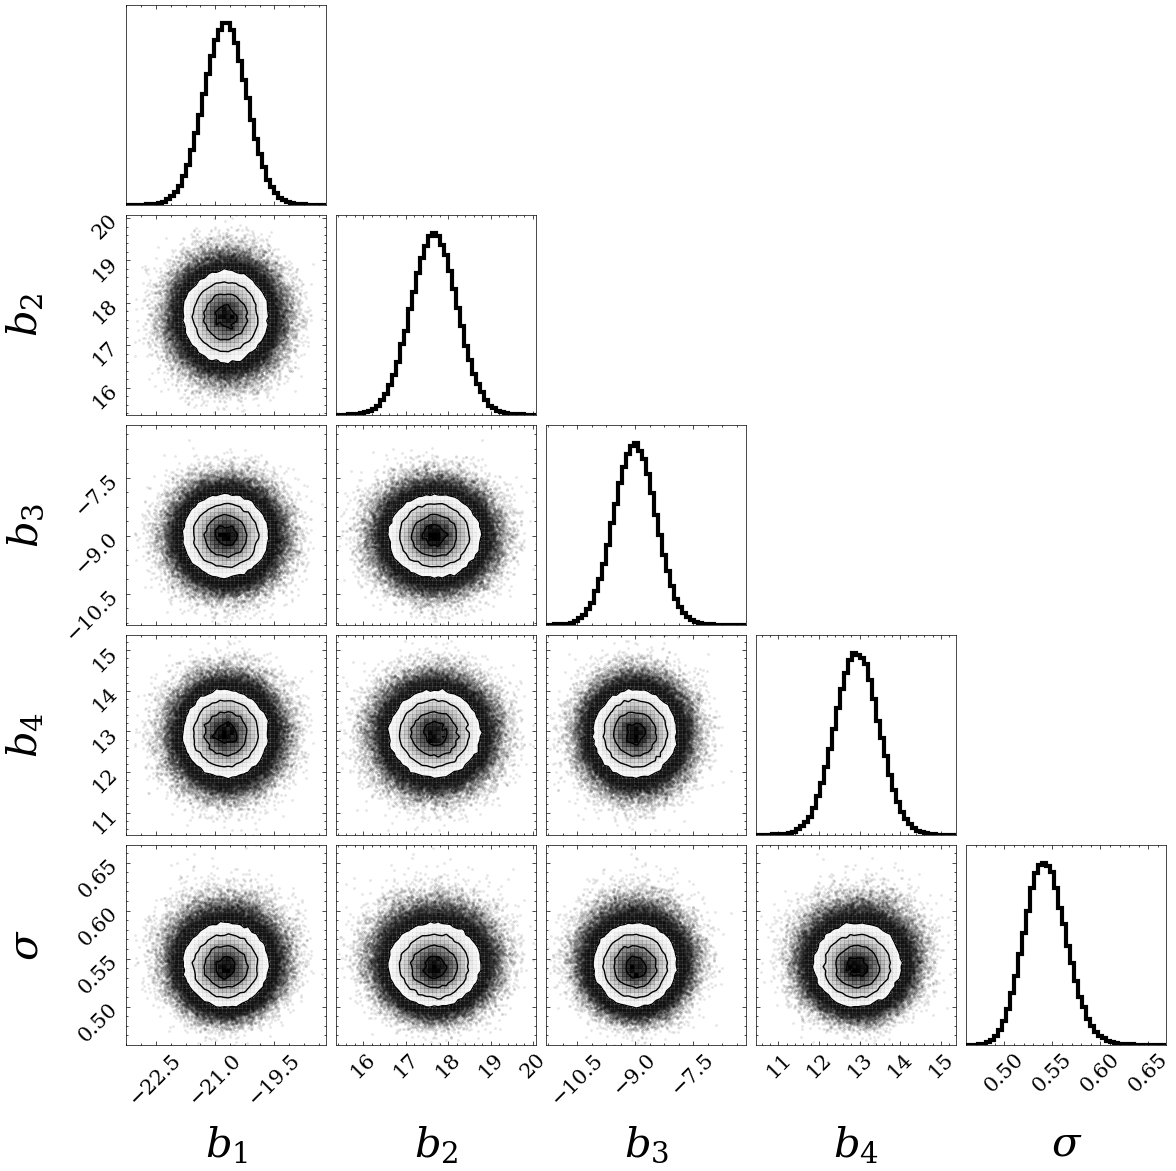

In [30]:
label_global = [f'$b_{i}$' for i in range(1, components_kept+1)]
label_global.append(f'$\sigma$')

plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)

figure = corner.corner(samples,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label_global, 
                    #    truths=np.append(beta,np.sqrt(sigma_squared)),
                    #    truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)
plt.show()

In [31]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights = []
for beta in samples:
    model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights= np.array(model_weights)

In [32]:
filtered_model_predictions_mass = filtered_models_output_mass.iloc[:,3:-1].values

In [33]:
lower_mass, median_mass, upper_mass = rndm_m_radius_calculator(model_weights, filtered_model_predictions_mass, samples)

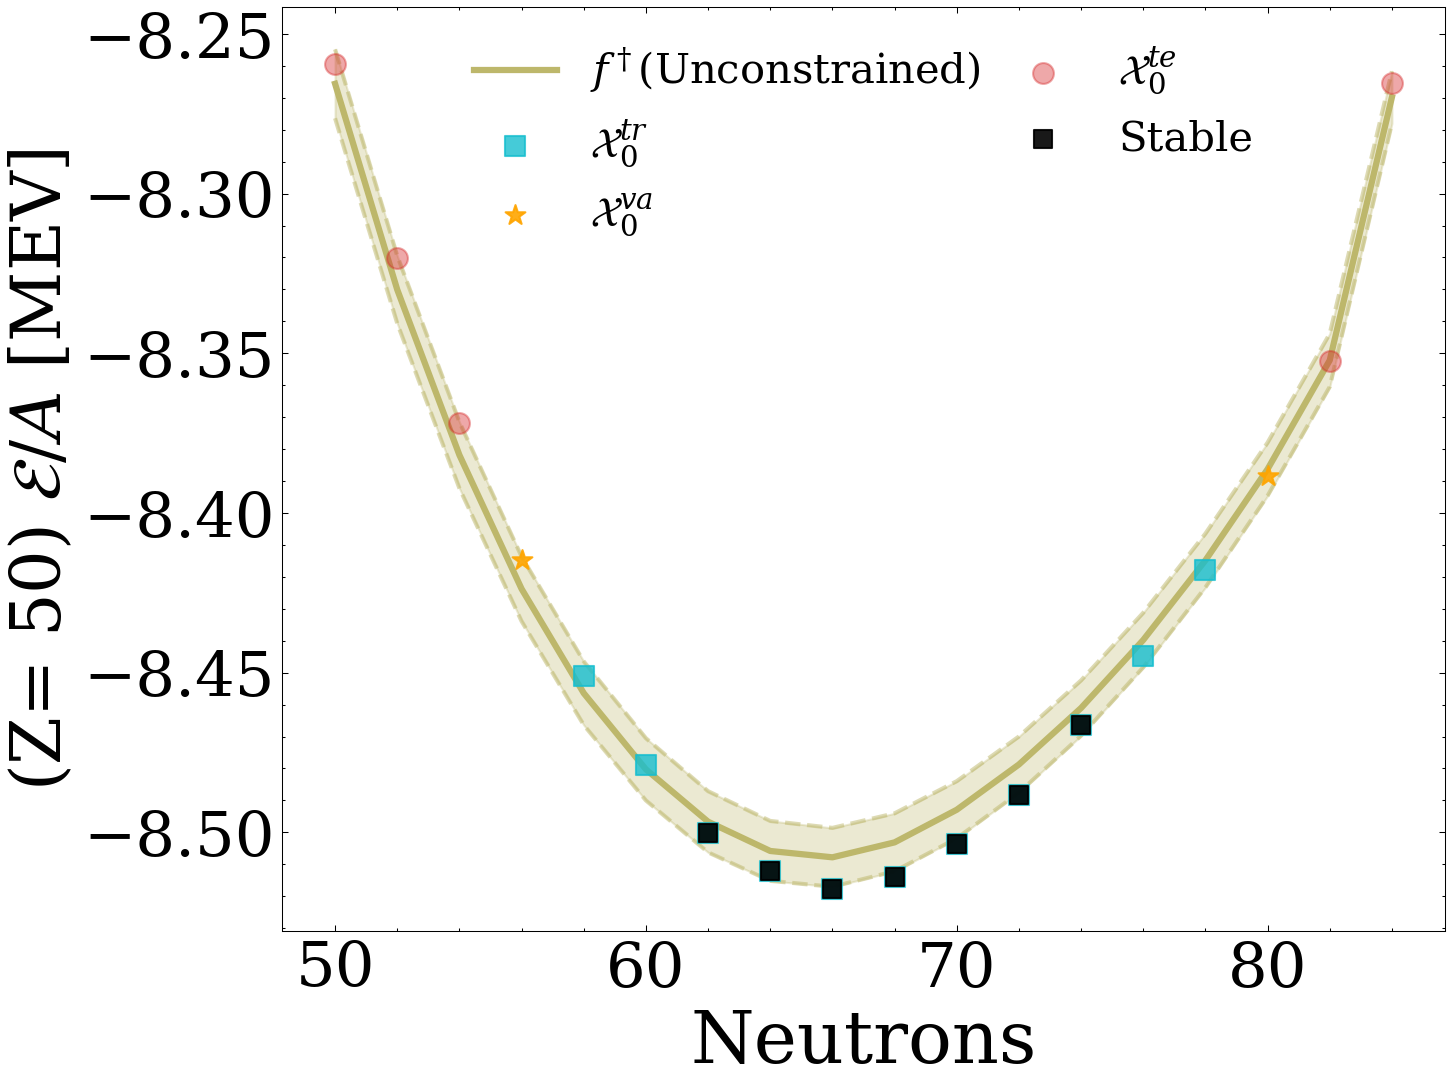

In [35]:
supermodel_predictions_mass_range = [lower_mass, median_mass, upper_mass]
# savefig_80_mass = 'Plots/Mass forecasts in unconstrained case for Z = 50.png'
plot_filtered_supermodel(supermodel_predictions_mass_range, filtered_models_output_mass_list, 50, 'MEV', 'E', 'Unconstrained')

In [36]:
filtered_model_predictions_radius = filtered_models_output_radius.iloc[:,3:-1].values

In [37]:
rndm_m_radius = []
for i in range(len(model_weights)):
    if centering_data:
        yvals_rand_radius= filtered_model_predictions_radius.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_radius.append(yvals_rand_radius +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_radius)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * (samples[i][-1]/50)**2 ) )))  
        
lower_radius = np.percentile(rndm_m_radius, 2.5, axis = 0)
median_radius = np.percentile(rndm_m_radius, 50, axis = 0)
upper_radius = np.percentile(rndm_m_radius, 97.5, axis = 0)

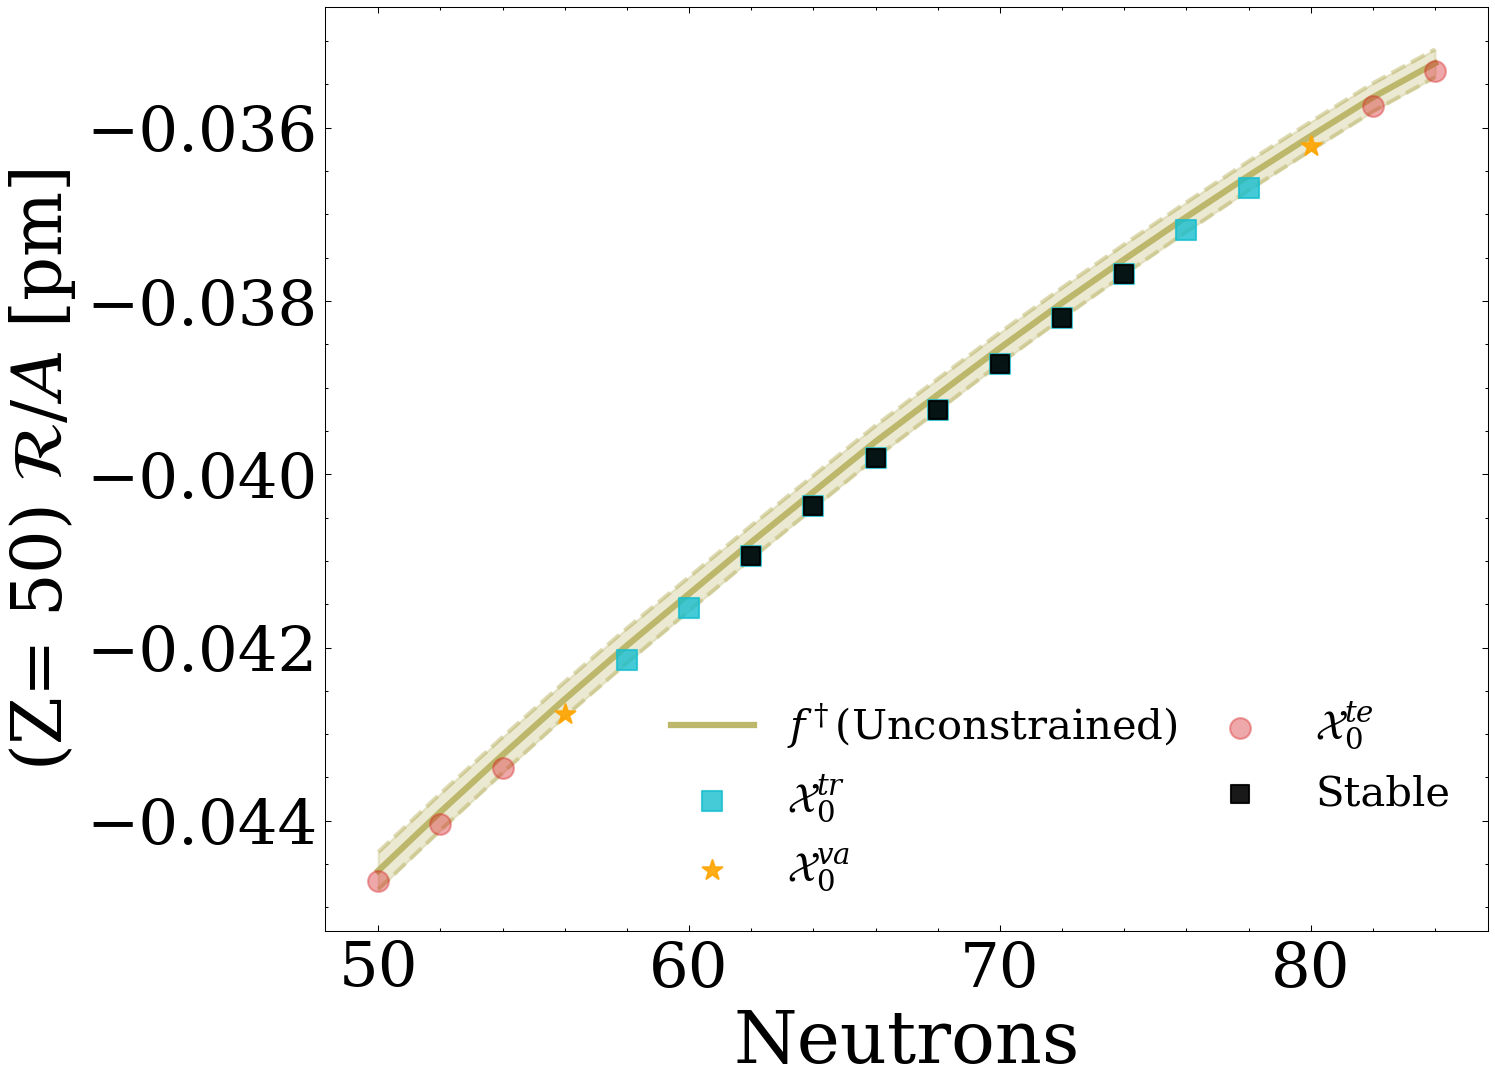

In [38]:
supermodel_predictions_radius_range = [lower_radius, median_radius, upper_radius]
# savefig_50_radius = 'Plots/Radius forecasts in unconstrained case for Z = 50.png'
plot_filtered_supermodel(supermodel_predictions_radius_range, filtered_models_output_radius_list, 50, 'pm', 'R', 'Unconstrained')

## Simplex 

In [39]:
nu0_chosen=10
sigma20_chosen=0.5
bias0=np.full(len(model_predictions_mass_train.T),1/len(model_predictions_mass_train.T))
#This term will be added to the \omegas when obtaining them from the \betas to account for centering the data

In [40]:
def gibbs_sampler_simplex(y, X, iterations,prior_info,burn=10000,stepsize=0.001):
    # if centering_data == False:
    #     print("Only available for centering data")
    #     return 
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
#     b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    
    nu0, sigma20  =  prior_info   #Since our prior is only in \sigma, we are letting the \betas be free beyond the simplex
    
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    cov_matrix_step=np.diag(S_hat**2*stepsize**2)
    
    n = len(y)
    
    #Initializing the starting point at the average of all the models
    b_current = np.full(len(X),0)

    
    
    supermodel_current=X.T.dot(b_current)
    

    residuals_current = y - supermodel_current 

    
  
    log_likelihood_current= -np.sum(residuals_current**2)
    
    
    sigma2 = -log_likelihood_current/ len(residuals_current) 

    
    
    samples = []
    acceptance=0
    
    for i in range(burn):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

        
            #Comment this line and uncomment the next if you want to check MCMC without the simplex  
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        
        else:
            
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed

        shape_post = (nu0 + n)/2.
        
        
#         scale_post = (nu0*sigma20 - log_likelihood_current/len(residuals_current))/2.0
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
#         samples.append(np.append(b_current,np.sqrt(sigma2)))
        
        
  

    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

    #Comment this line and uncomment the next if you want to check MCMC without the simplex    
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        else:
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed
                acceptance=acceptance+1

        shape_post = (nu0 + n)/2.
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))        
        
        
        
        
        
        
    

    print("percentage accepted:", round(acceptance/iterations*100))
    return np.array(samples)

In [41]:
%%time
samples_simplex=gibbs_sampler_simplex(y_mass, X.T, 500000,[nu0_chosen, sigma20_chosen],burn=300000,stepsize=0.0008)

percentage accepted: 52
CPU times: total: 4min 47s
Wall time: 7min 4s


In [42]:
label_global = [f'$b_{i}$' for i in range(1, components_kept+1)]
label_global.append(f'$\sigma$')

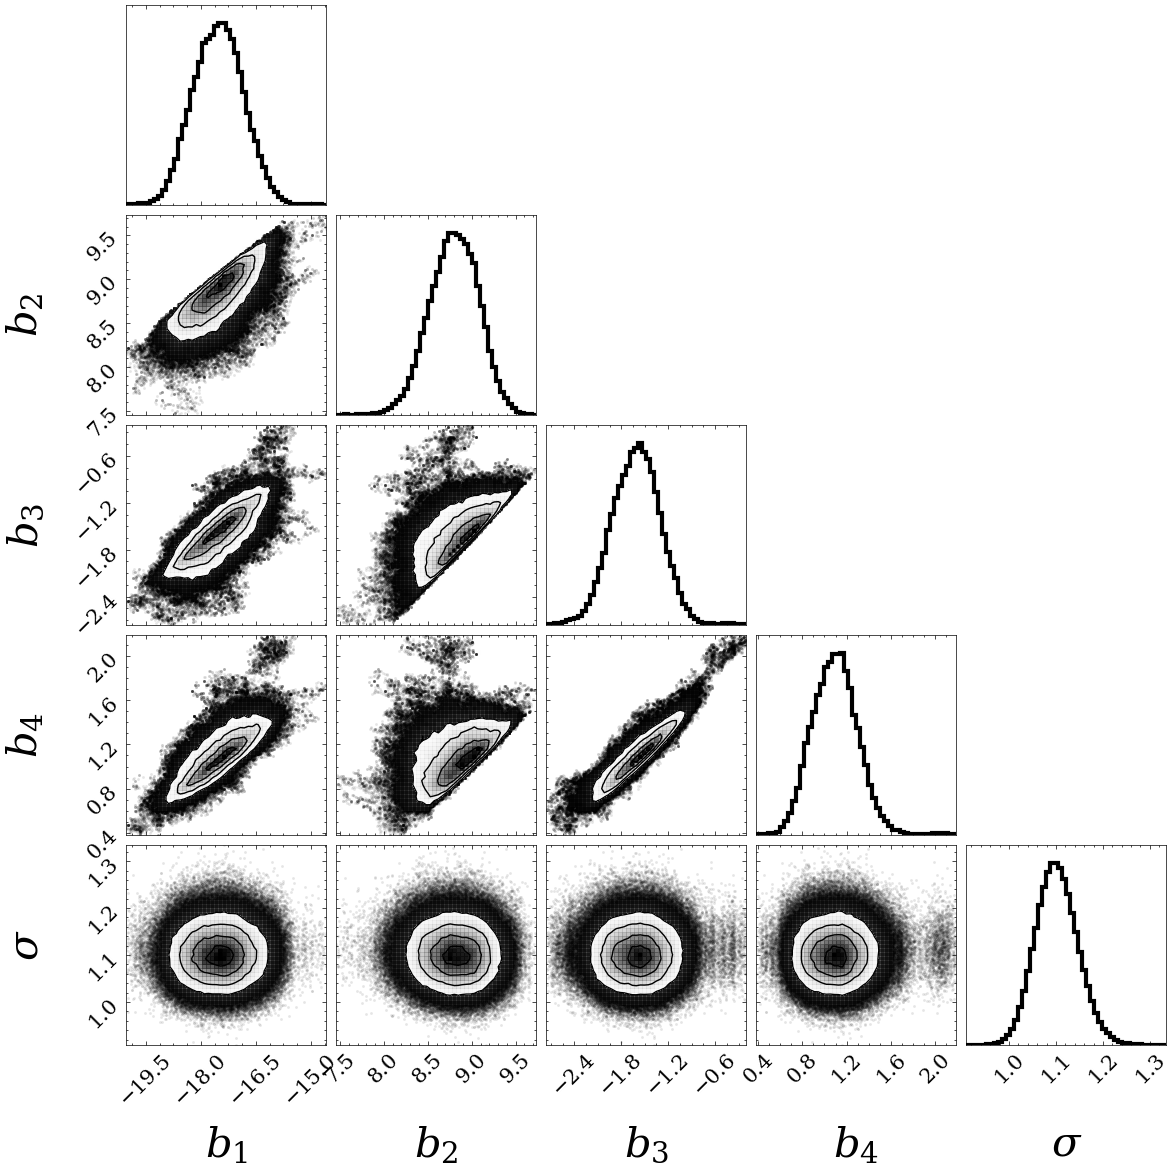

In [43]:
plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)

figure = corner.corner(samples_simplex,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label_global, 
                    #    truths=np.append(beta,np.sqrt(sigma_squared)),
                    #    truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)
plt.show()

In [44]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights_simplex = []
for beta in samples_simplex:
    model_weights_simplex.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights_simplex = np.array(model_weights_simplex)

In [45]:
model_weights_simplex.shape

(500000, 9)

In [46]:
lower_mass_simplex, median_mass_simplex, upper_mass_simplex = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_mass, samples_simplex)

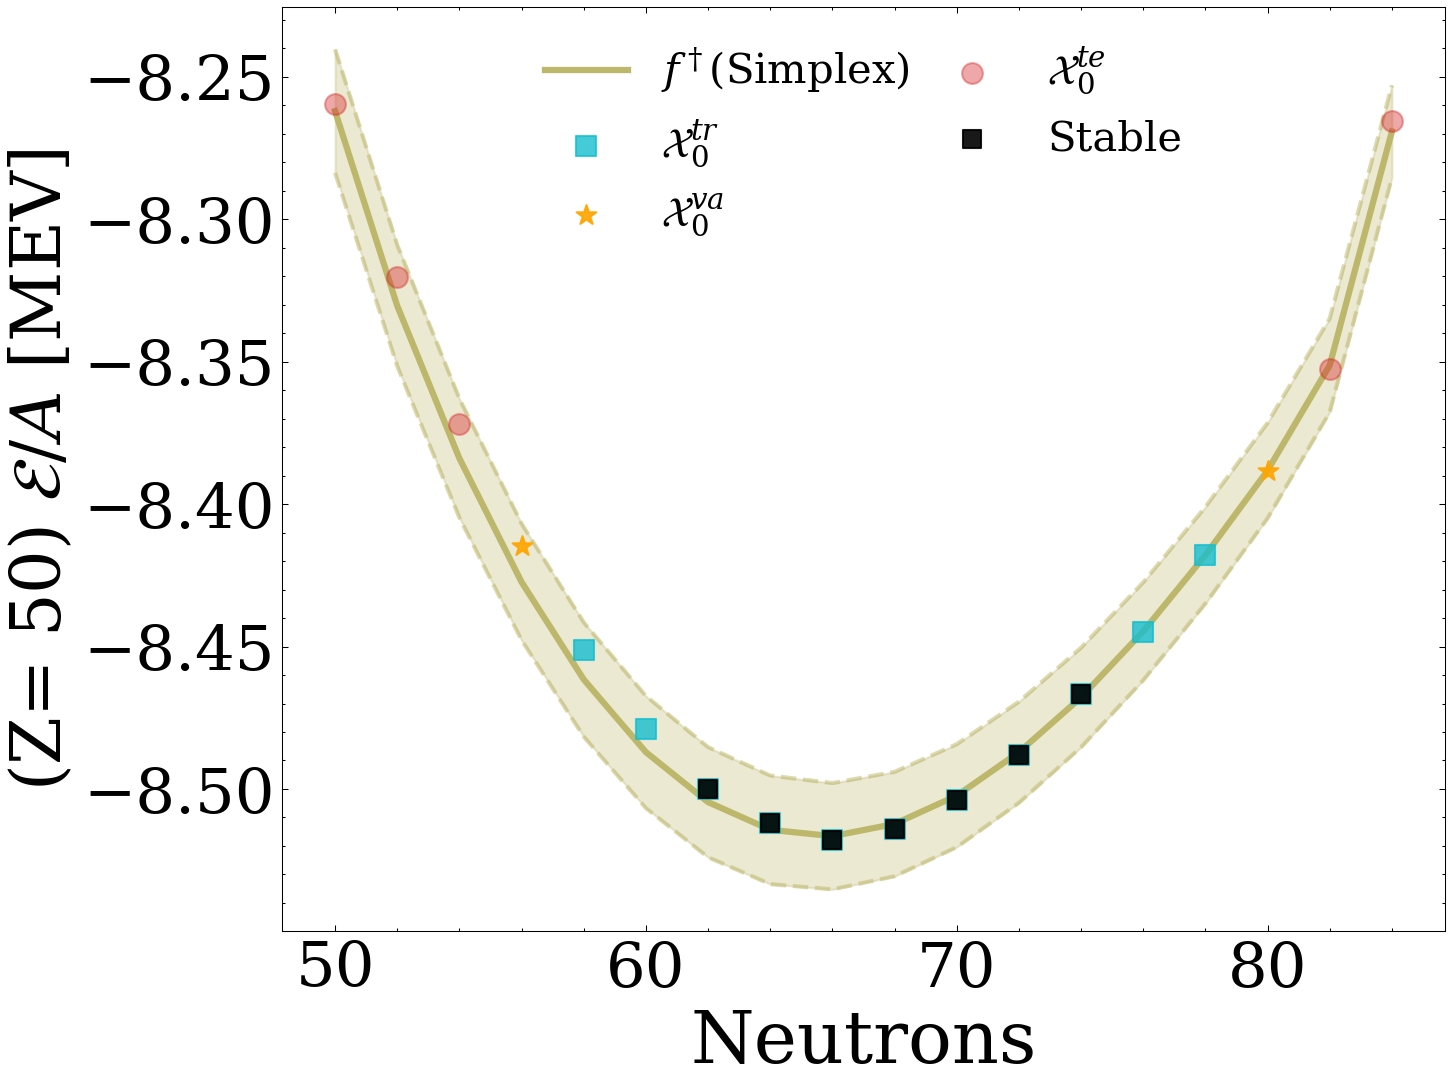

In [47]:
supermodel_predictions_mass_range_simplex = [lower_mass_simplex, median_mass_simplex, upper_mass_simplex]
# savefig_50_mass_simplex = 'Plots/Mass forecasts in simplex case for Z = 50.png'
plot_filtered_supermodel(supermodel_predictions_mass_range_simplex, filtered_models_output_mass_list, 50, 'MEV', 'E', 'Simplex')

In [48]:
filtered_model_predictions_radius = filtered_models_output_radius.iloc[:,3:-1].values

In [49]:
rndm_m_radius_simplex = []
for i in range(len(model_weights_simplex)):
    if centering_data:
        yvals_rand_radius= filtered_model_predictions_radius.dot(model_weights_simplex[i].T)
    # else:
    #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])

    rndm_m_radius_simplex.append(yvals_rand_radius +
                   np.random.multivariate_normal(np.full(
                       len(yvals_rand_radius)
                       ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * (samples_simplex[i][-1]/50)**2 ) )))  
lower_radius_simplex = np.percentile(rndm_m_radius_simplex, 2.5, axis = 0)
median_radius_simplex = np.percentile(rndm_m_radius_simplex, 50, axis = 0)
upper_radius_simplex = np.percentile(rndm_m_radius_simplex, 97.5, axis = 0)

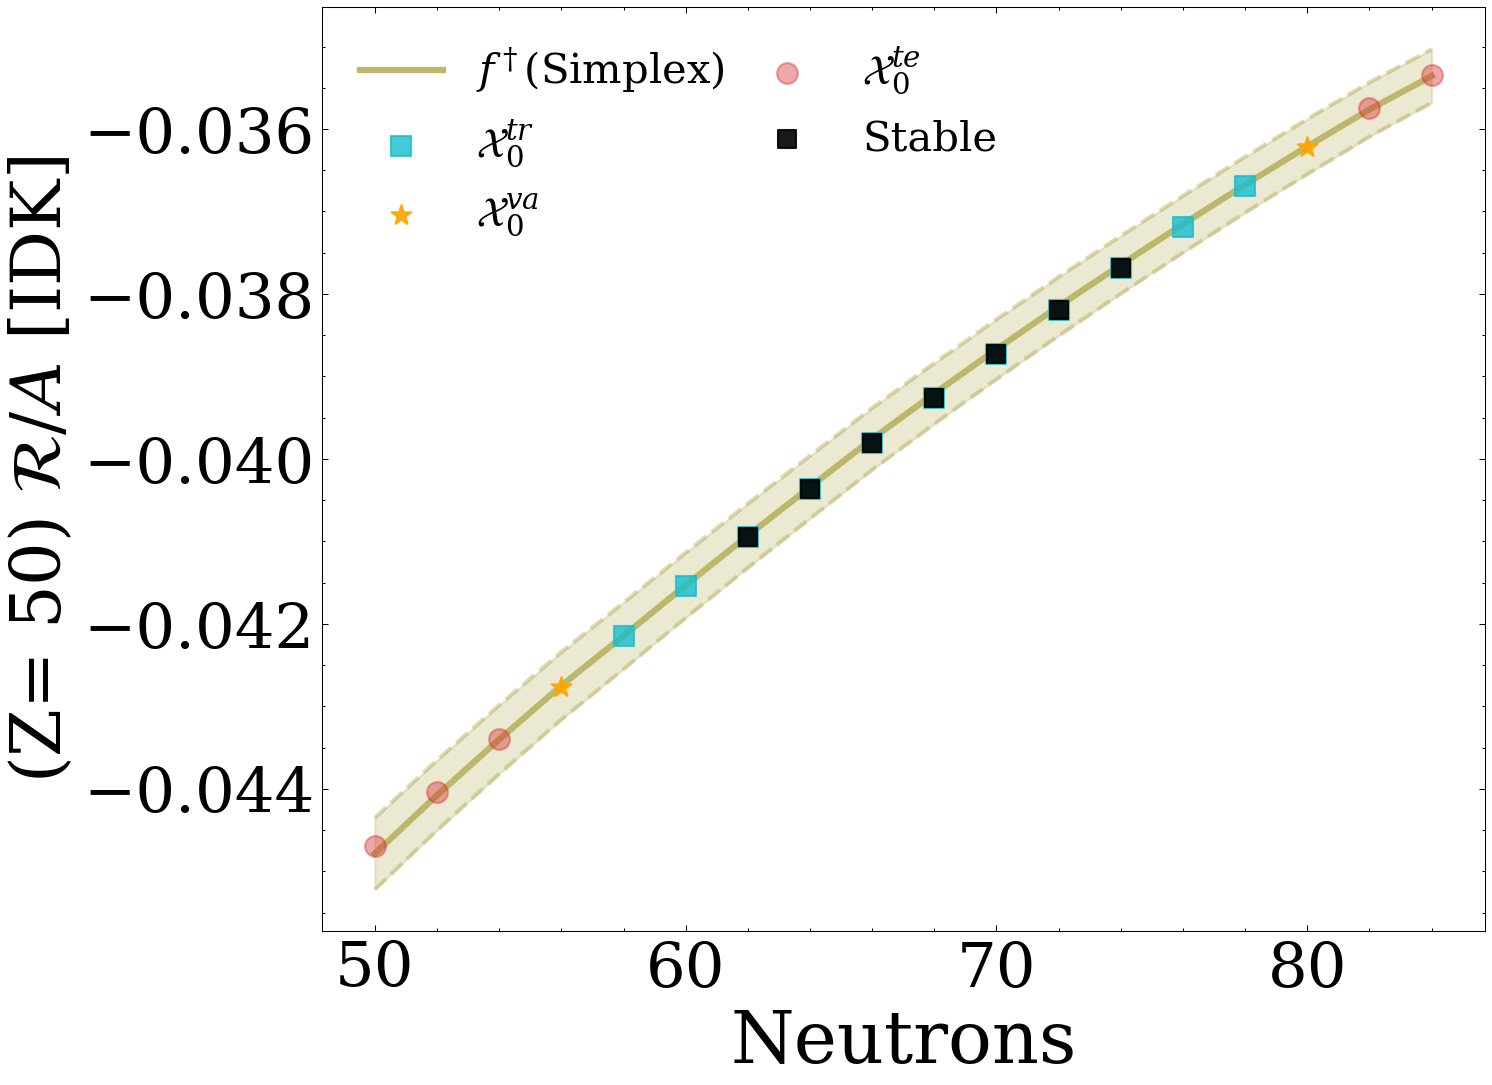

In [50]:
supermodel_predictions_radius_range_simplex = [lower_radius_simplex, median_radius_simplex, upper_radius_simplex]
# savefig_50_radius_simplex = 'Plots/Radius forecasts in simplex case for Z = 50.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_simplex, filtered_models_output_radius_list, 50, 'IDK', 'R', 'Simplex')

# Z = 60

In [51]:
filtered_models_output_mass_list_60 = filtered_models_output(60, models_output_mass_list)
filtered_models_output_radius_list_60 = filtered_models_output(60, models_output_radius_list)

filtered_models_output_mass_60 = filtered_models_output_mass_list_60[0]
filtered_models_output_radius_60 = filtered_models_output_radius_list_60[0]

filtered_model_predictions_mass_60 = filtered_models_output_mass_60.iloc[:,3:-1].values
filtered_model_predictions_radius_60 = filtered_models_output_radius_60.iloc[:,3:-1].values

In [52]:
lower_mass_simplex_60, median_mass_simplex_60, upper_mass_simplex_60 = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_mass_60, samples_simplex)

In [53]:
rndm_m_radius_simplex_60 = []
for i in range(len(model_weights_simplex)):
    if centering_data:
        yvals_rand_radius_60= filtered_model_predictions_radius_60.dot(model_weights_simplex[i].T)
    # else:
    #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])

    rndm_m_radius_simplex_60.append(yvals_rand_radius_60 +
                   np.random.multivariate_normal(np.full(
                       len(yvals_rand_radius_60)
                       ,0), np.diag(1.0 * np.full(len(yvals_rand_radius_60),1.0 * (samples_simplex[i][-1]/50)**2 ) )))  
lower_radius_simplex_60 = np.percentile(rndm_m_radius_simplex_60, 2.5, axis = 0)
median_radius_simplex_60 = np.percentile(rndm_m_radius_simplex_60, 50, axis = 0)
upper_radius_simplex_60 = np.percentile(rndm_m_radius_simplex_60, 97.5, axis = 0)

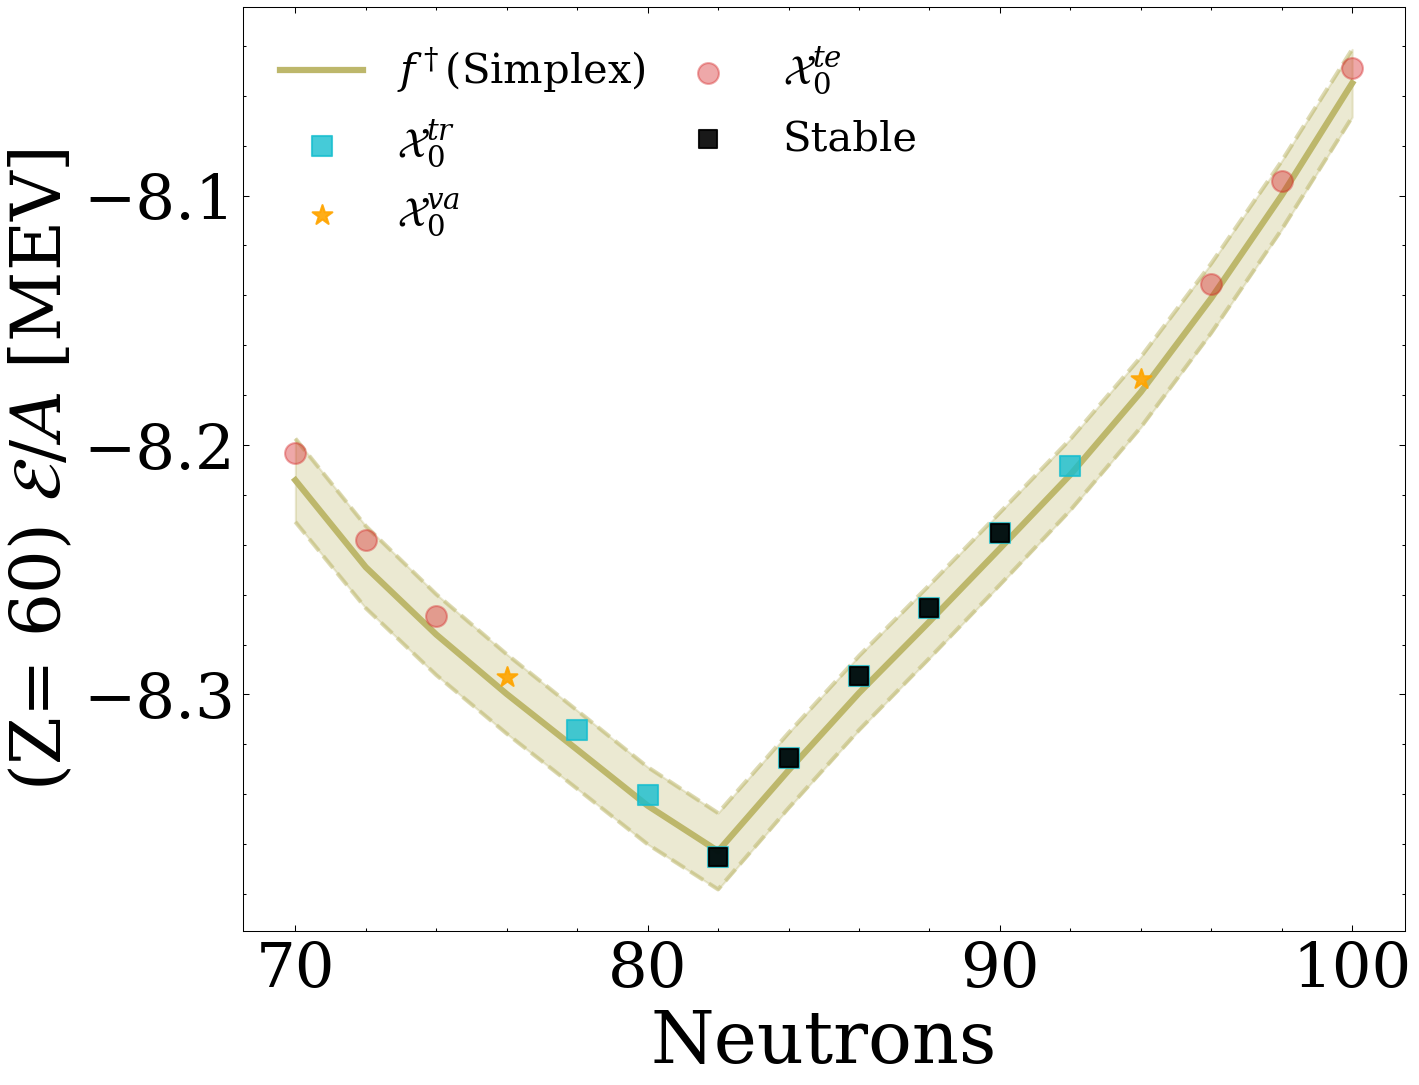

In [54]:
supermodel_predictions_mass_range_simplex_60 = [lower_mass_simplex_60, median_mass_simplex_60, upper_mass_simplex_60]
# savefig_60_mass_simplex = 'Plots/Mass forecasts in simplex case for Z = 60.png'
plot_filtered_supermodel(supermodel_predictions_mass_range_simplex_60, filtered_models_output_mass_list_60, 60, 'MEV', 'E', 'Simplex')

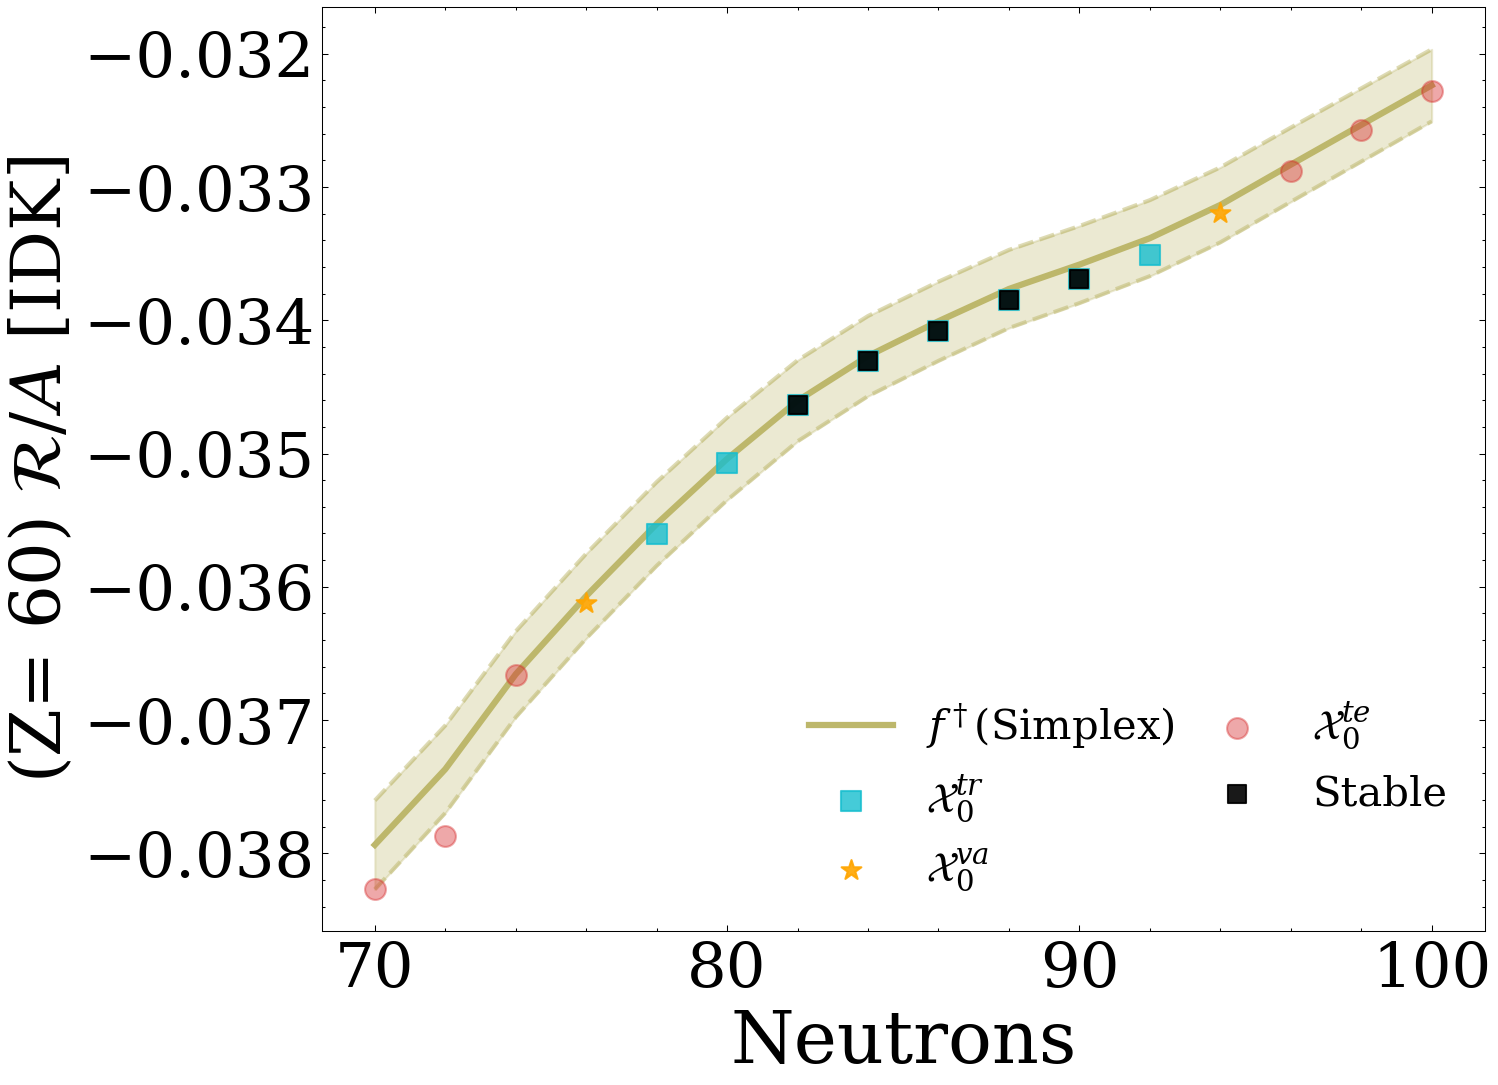

In [55]:
supermodel_predictions_radius_range_simplex_60 = [lower_radius_simplex_60, median_radius_simplex_60, upper_radius_simplex_60]
# savefig_60_radius_simplex = 'Plots/Radius forecasts in simplex case for Z = 60.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_simplex_60, filtered_models_output_radius_list_60, 60, 'IDK', 'R', 'Simplex')

# Z = 70

In [56]:
filtered_models_output_mass_list_70 = filtered_models_output(70, models_output_mass_list)
filtered_models_output_radius_list_70 = filtered_models_output(70, models_output_radius_list)

filtered_models_output_mass_70 = filtered_models_output_mass_list_70[0]
filtered_models_output_radius_70 = filtered_models_output_radius_list_70[0]

filtered_model_predictions_mass_70 = filtered_models_output_mass_70.iloc[:,3:-1].values
filtered_model_predictions_radius_70 = filtered_models_output_radius_70.iloc[:,3:-1].values

In [57]:
lower_mass_simplex_70, median_mass_simplex_70, upper_mass_simplex_70 = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_mass_70, samples_simplex)

In [58]:
rndm_m_radius_simplex_70 = []
for i in range(len(model_weights_simplex)):
    if centering_data:
        yvals_rand_radius_70= filtered_model_predictions_radius_70.dot(model_weights_simplex[i].T)
    # else:
    #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])

    rndm_m_radius_simplex_70.append(yvals_rand_radius_70 +
                   np.random.multivariate_normal(np.full(
                       len(yvals_rand_radius_70)
                       ,0), np.diag(1.0 * np.full(len(yvals_rand_radius_70),1.0 * (samples_simplex[i][-1]/50)**2 ) )))  
lower_radius_simplex_70 = np.percentile(rndm_m_radius_simplex_70, 2.5, axis = 0)
median_radius_simplex_70 = np.percentile(rndm_m_radius_simplex_70, 50, axis = 0)
upper_radius_simplex_70 = np.percentile(rndm_m_radius_simplex_70, 97.5, axis = 0)

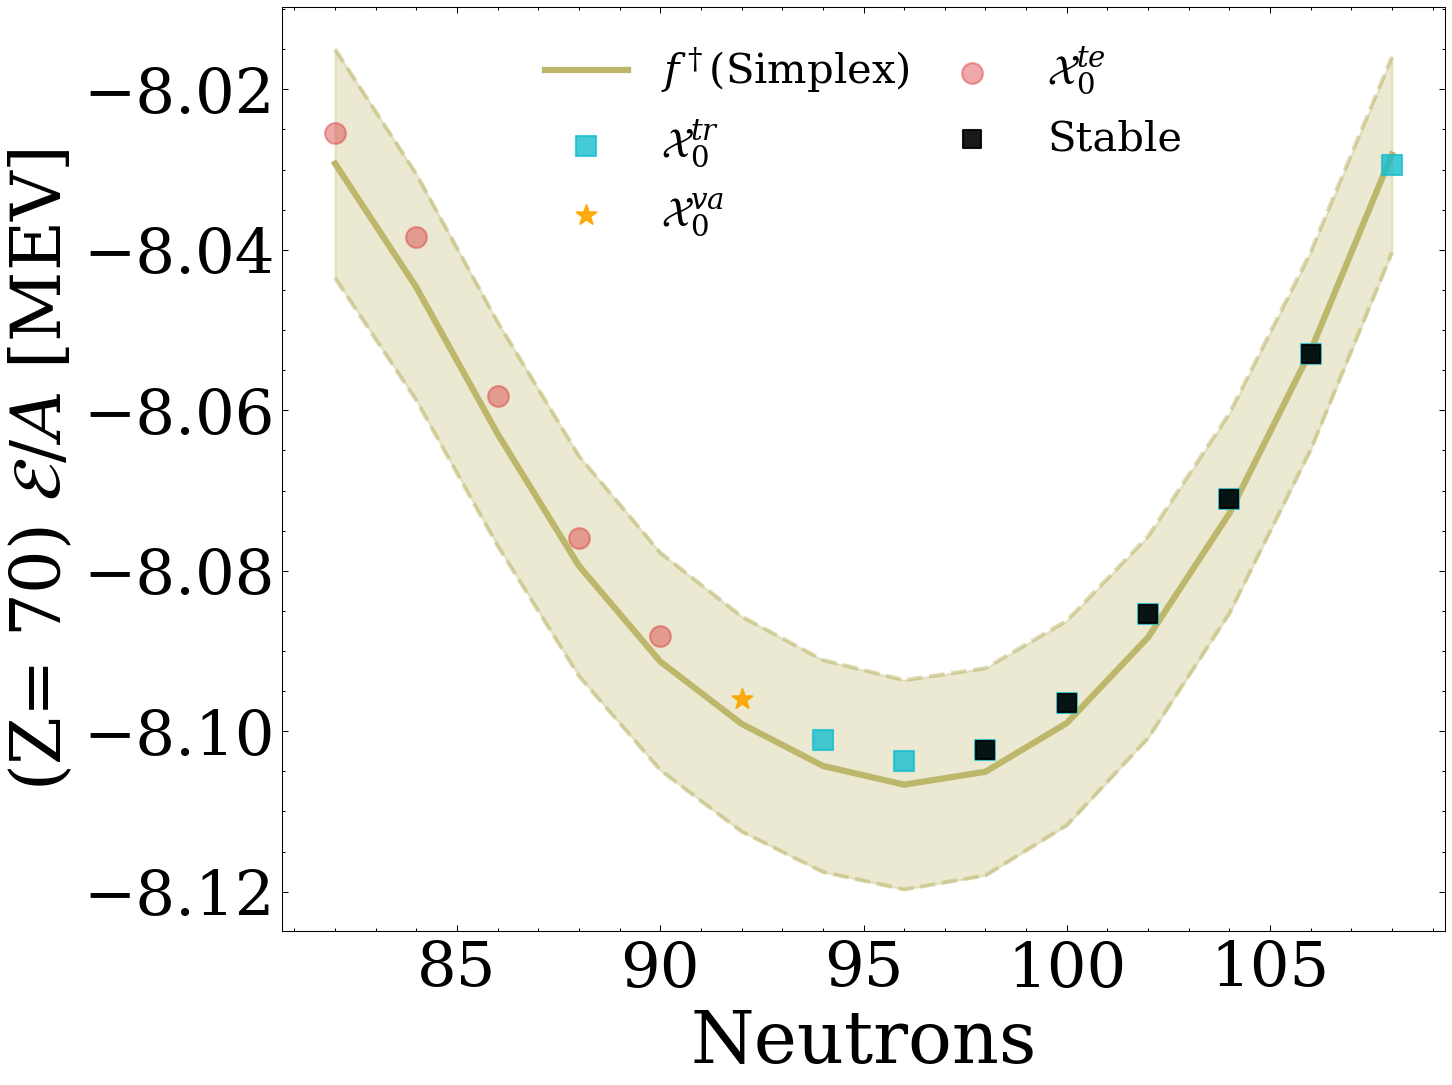

In [59]:
supermodel_predictions_mass_range_simplex_70 = [lower_mass_simplex_70, median_mass_simplex_70, upper_mass_simplex_70]
# savefig_70_mass_simplex = 'Plots/Mass forecasts in simplex case for Z = 70.png'
plot_filtered_supermodel(supermodel_predictions_mass_range_simplex_70, filtered_models_output_mass_list_70, 70, 'MEV', 'E', 'Simplex')

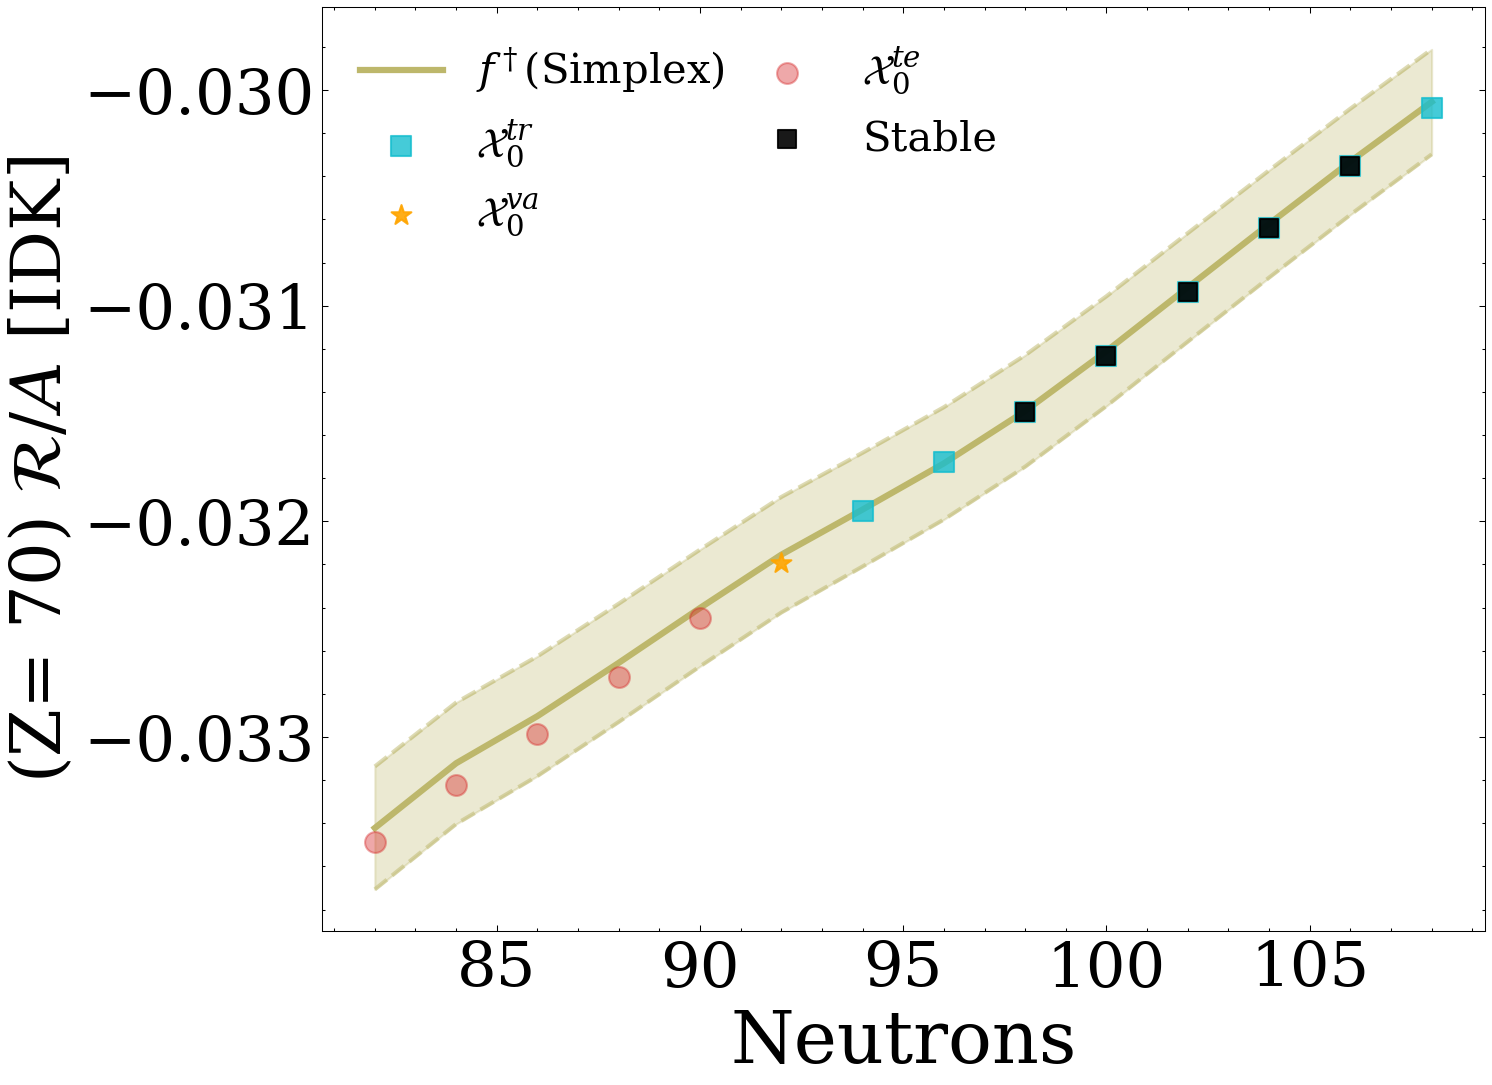

In [60]:
supermodel_predictions_radius_range_simplex_70 = [lower_radius_simplex_70, median_radius_simplex_70, upper_radius_simplex_70]
savefig_70_radius_simplex = 'Plots/Radius forecasts in simplex case for Z = 70.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_simplex_70, filtered_models_output_radius_list_70, 70, 'IDK', 'R', 'Simplex')

# Z = 80

In [61]:
filtered_models_output_mass_list_80 = filtered_models_output(80, models_output_mass_list)
filtered_models_output_radius_list_80 = filtered_models_output(80, models_output_radius_list)

filtered_models_output_mass_80 = filtered_models_output_mass_list_80[0]
filtered_models_output_radius_80 = filtered_models_output_radius_list_80[0]

filtered_model_predictions_mass_80 = filtered_models_output_mass_80.iloc[:,3:-1].values
filtered_model_predictions_radius_80 = filtered_models_output_radius_80.iloc[:,3:-1].values

In [62]:
lower_mass_simplex_80, median_mass_simplex_80, upper_mass_simplex_80 = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_mass_80, samples_simplex)

In [63]:
rndm_m_radius_simplex_80 = []
for i in range(len(model_weights_simplex)):
    if centering_data:
        yvals_rand_radius_80= filtered_model_predictions_radius_80.dot(model_weights_simplex[i].T)
    # else:
    #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])

    rndm_m_radius_simplex_80.append(yvals_rand_radius_80 +
                   np.random.multivariate_normal(np.full(
                       len(yvals_rand_radius_80)
                       ,0), np.diag(1.0 * np.full(len(yvals_rand_radius_80),1.0 * (samples_simplex[i][-1]/50)**2 ) )))  
lower_radius_simplex_80 = np.percentile(rndm_m_radius_simplex_80, 2.5, axis = 0)
median_radius_simplex_80 = np.percentile(rndm_m_radius_simplex_80, 50, axis = 0)
upper_radius_simplex_80 = np.percentile(rndm_m_radius_simplex_80, 97.5, axis = 0)

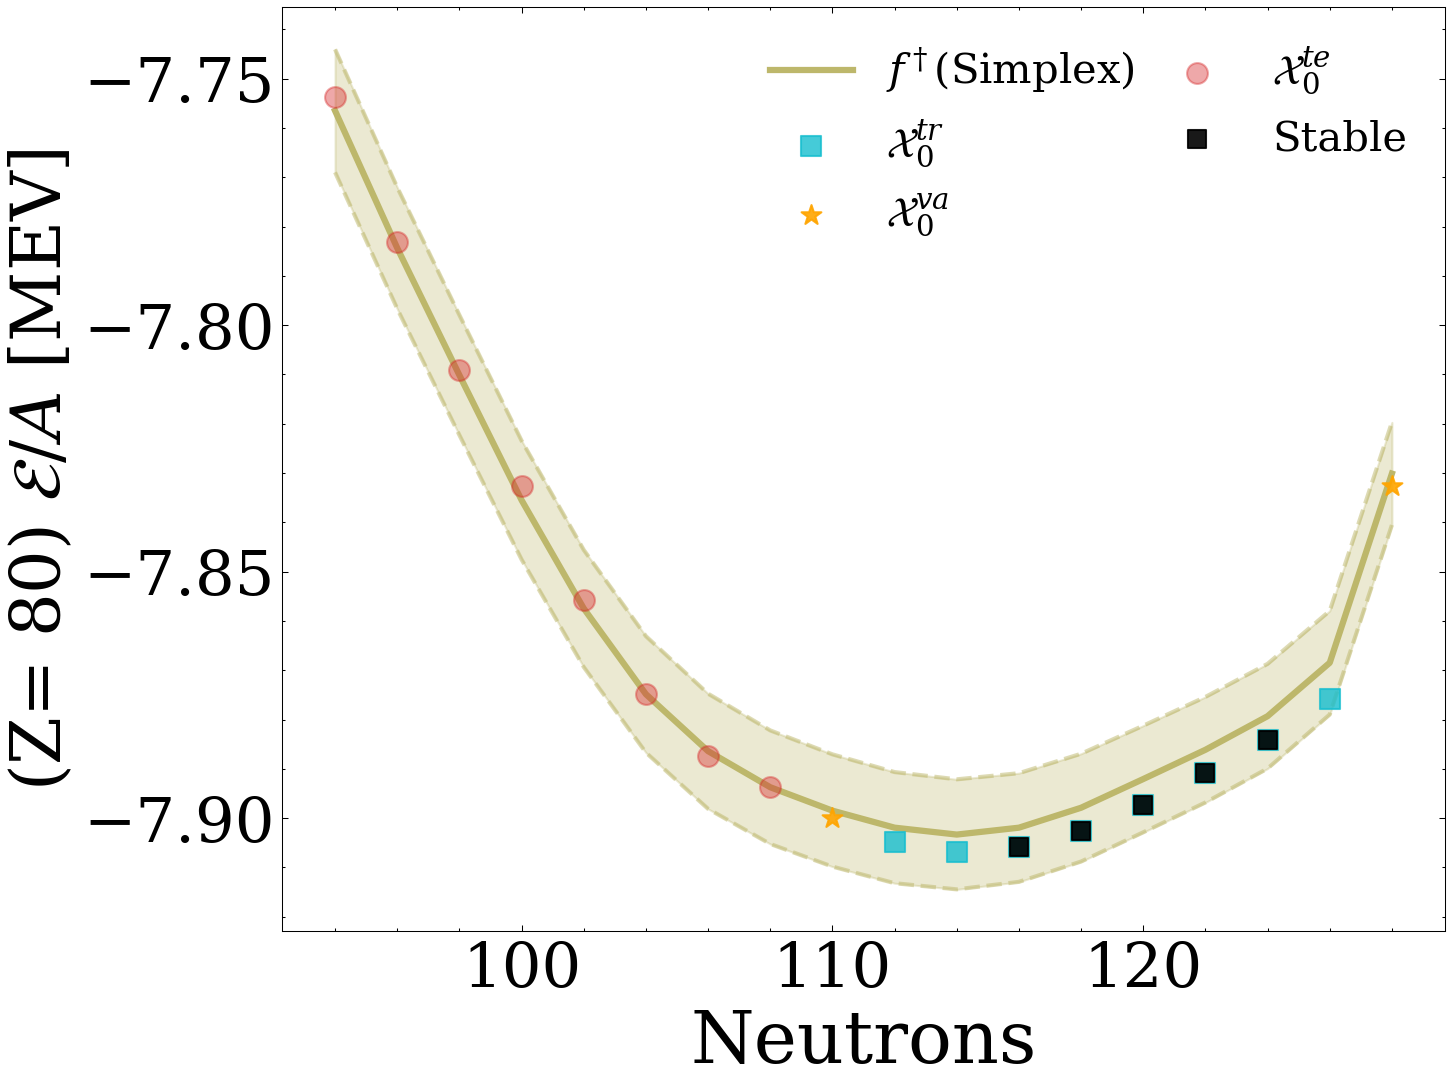

In [64]:
supermodel_predictions_mass_range_simplex_80 = [lower_mass_simplex_80, median_mass_simplex_80, upper_mass_simplex_80]
# savefig_80_mass_simplex = 'Plots/Mass forecasts in simplex case for Z = 80.png'
plot_filtered_supermodel(supermodel_predictions_mass_range_simplex_80, filtered_models_output_mass_list_80, 80, 'MEV', 'E', 'Simplex')

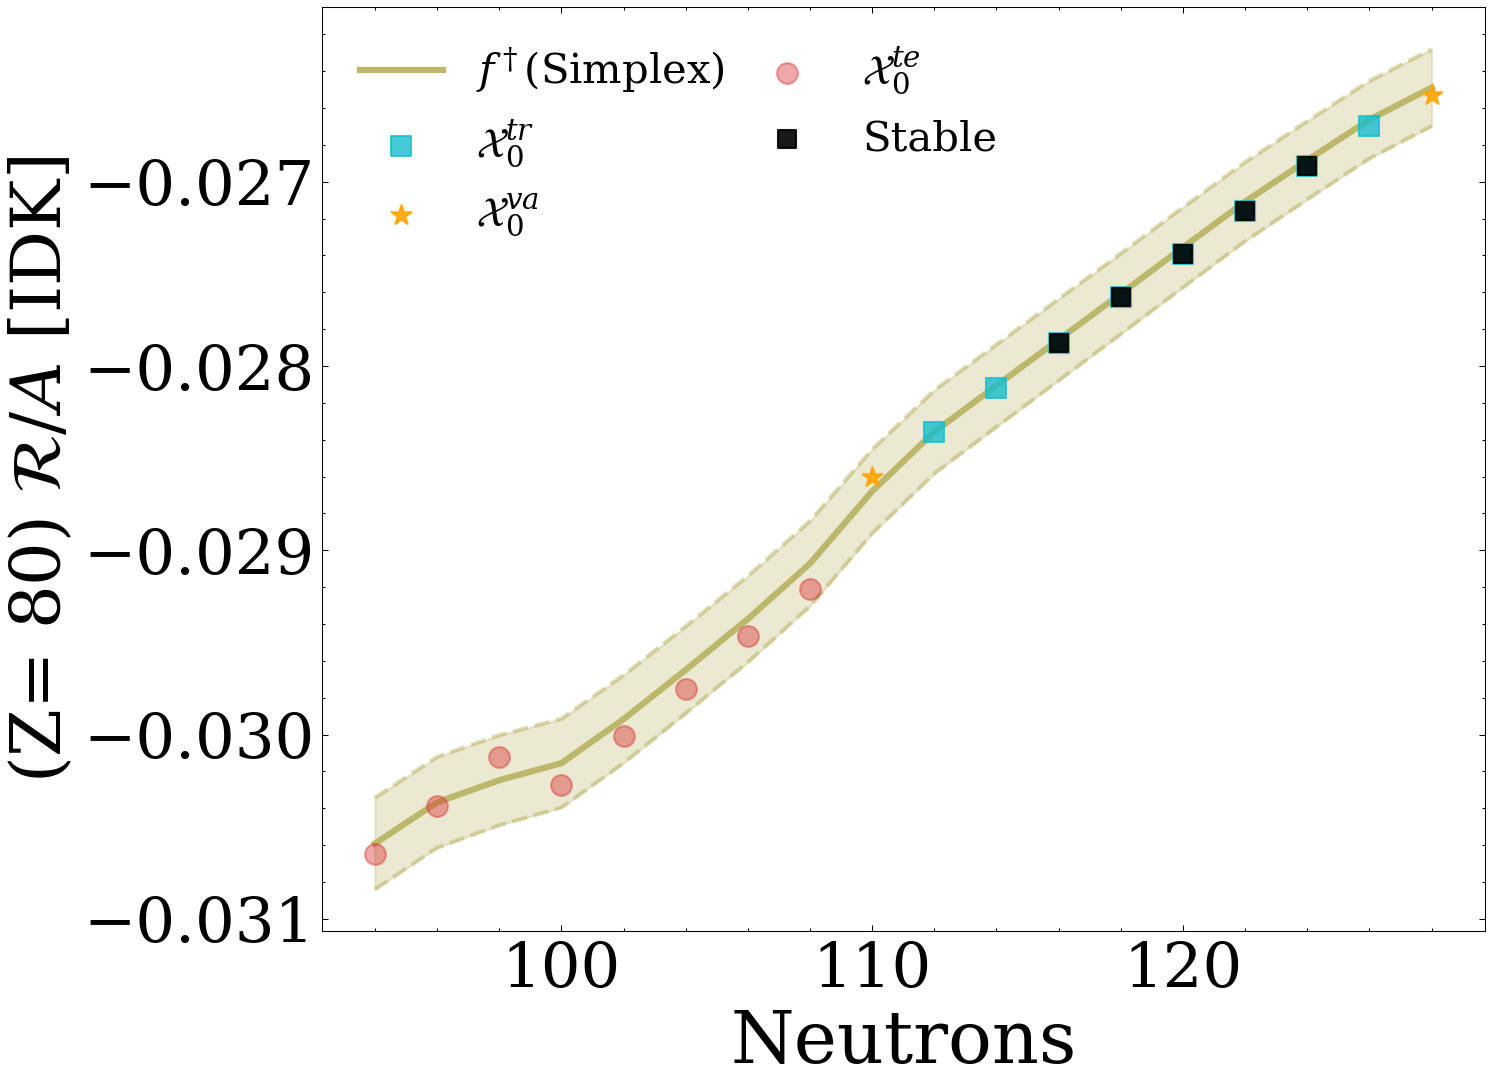

In [65]:
supermodel_predictions_radius_range_simplex_80 = [lower_radius_simplex_80, median_radius_simplex_80, upper_radius_simplex_80]
# savefig_80_radius_simplex = 'Plots/Radius forecasts in simplex case for Z = 80.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_simplex_80, filtered_models_output_radius_list_80, 80, 'IDK', 'R', 'Simplex')

## Let's evaluate how our analysis work for coverage of actual data

In [66]:
rndm_m_full_mass_train_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_train, 5000, Vt_hat)

100%|██████████| 5000/5000 [01:11<00:00, 70.01it/s]


In [67]:
rndm_m_full_mass_train_simplex.shape

(5000, 300)

In [68]:
rndm_m_full_mass_validation_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_validation, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:05<00:00, 997.37it/s] 


In [69]:
rndm_m_full_mass_test_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_test, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:57<00:00, 86.32it/s]


In [70]:
rndm_m_full_radius_train_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_train, 5000, Vt_hat)

100%|██████████| 5000/5000 [01:09<00:00, 71.46it/s]


In [71]:
rndm_m_full_radius_validation_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_validation, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:04<00:00, 1095.06it/s]


In [72]:
rndm_m_full_radius_test_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_test, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:58<00:00, 86.02it/s]


In [73]:
coverage_mass_train_simplex = coverage_calculation(rndm_m_full_mass_train_simplex, models_output_mass_train)

In [74]:
coverage_mass_validation_simplex = coverage_calculation(rndm_m_full_mass_validation_simplex, models_output_mass_validation)

In [75]:
coverage_mass_test_simplex = coverage_calculation(rndm_m_full_mass_test_simplex, models_output_mass_test)

In [76]:
percentiles = np.arange(0,101,5)

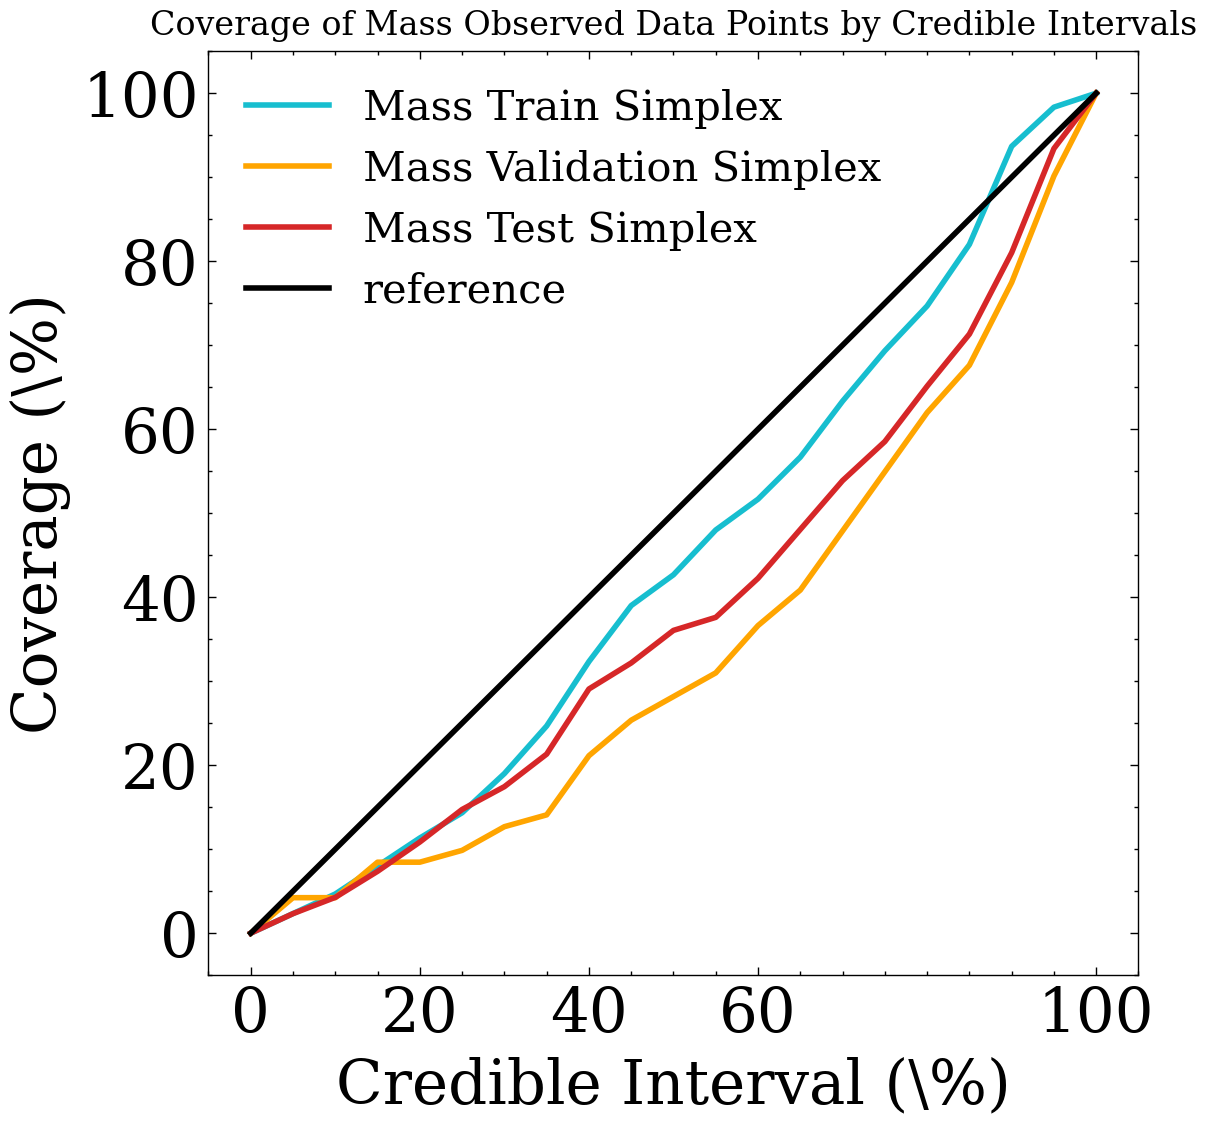

In [77]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_mass_train_simplex, label='Mass Train Simplex',color=color_trainig,linewidth=width_line)
plt.plot(percentiles, coverage_mass_validation_simplex, label='Mass Validation Simplex',color=color_validation,linewidth=width_line)
plt.plot(percentiles, coverage_mass_test_simplex, label='Mass Test Simplex',color=color_testing,linewidth=width_line)


# plt.plot(percentiles, coverage_train_simplex,linestyle='dashed', label='Training',color=color_trainig,linewidth=width_line)
# plt.plot(percentiles, coverage_validation_simplex, linestyle='dashed',label='Validation',color=color_validation,linewidth=width_line)
# plt.plot(percentiles, coverage_test_simplex,linestyle='dashed', label='Test',color=color_testing,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=width_line)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,100])

plt.title('Coverage of Mass Observed Data Points by Credible Intervals')
# plt.grid(True)
plt.legend(fontsize=15)
# plt.savefig('Plots/Mass-Only Coverage Graph of Simplex case.png')
plt.show()

In [78]:
coverage_radius_train_simplex = coverage_calculation(rndm_m_full_radius_train_simplex, models_output_radius_train)

In [79]:
coverage_radius_validation_simplex = coverage_calculation(rndm_m_full_radius_validation_simplex, models_output_radius_validation)

In [80]:
coverage_radius_test_simplex = coverage_calculation(rndm_m_full_radius_test_simplex, models_output_radius_test)

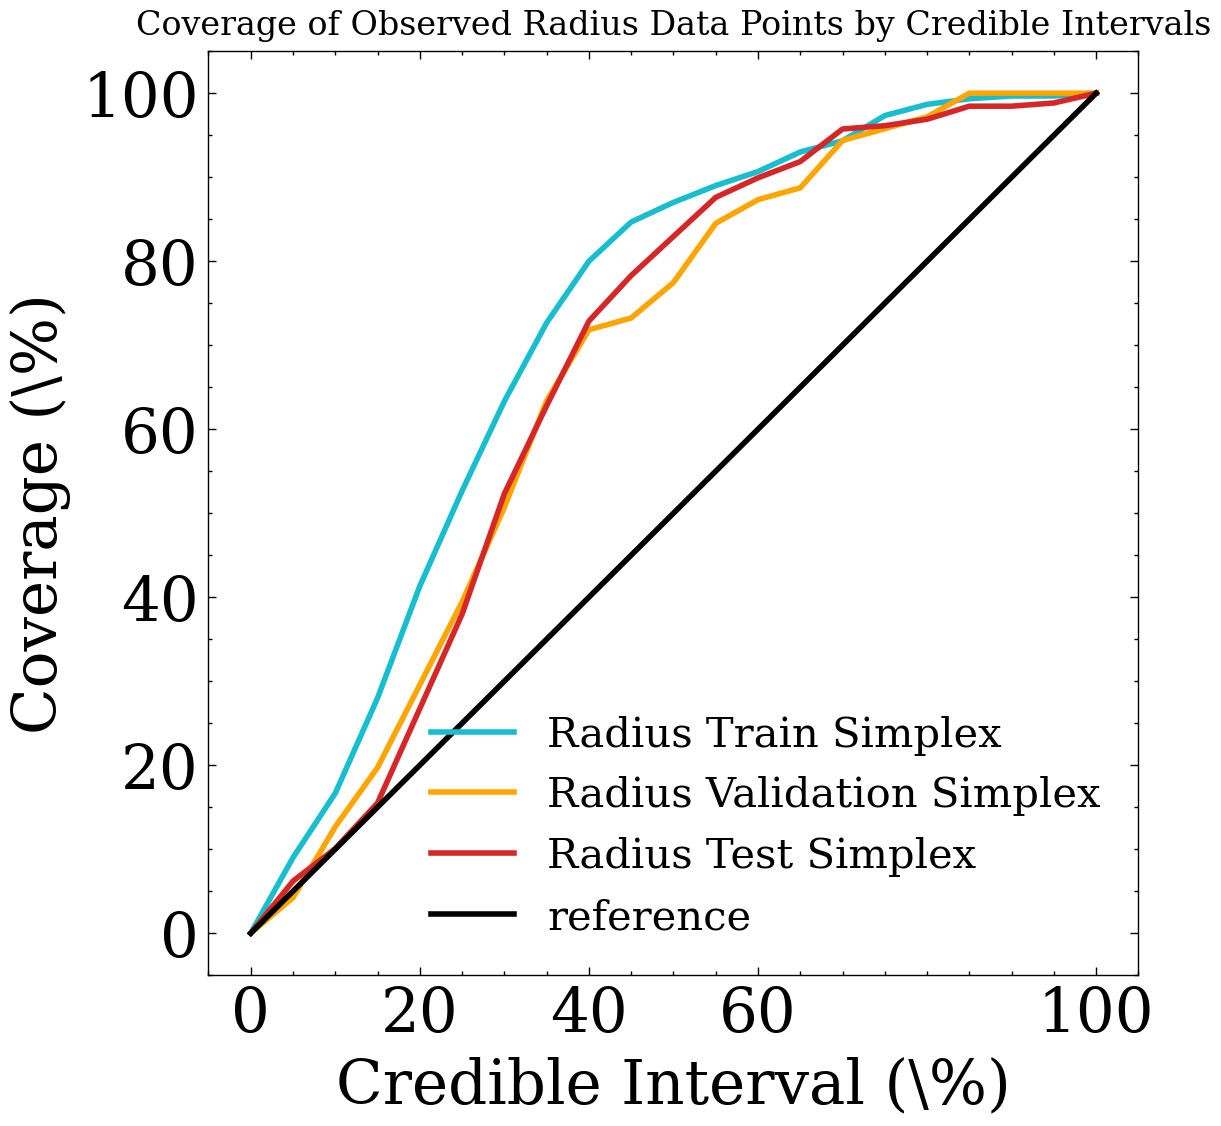

In [81]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_radius_train_simplex, label='Radius Train Simplex',color=color_trainig,linewidth=width_line)
plt.plot(percentiles, coverage_radius_validation_simplex, label='Radius Validation Simplex',color=color_validation,linewidth=width_line)
plt.plot(percentiles, coverage_radius_test_simplex, label='Radius Test Simplex',color=color_testing,linewidth=width_line)


# plt.plot(percentiles, coverage_train_simplex,linestyle='dashed', label='Training',color=color_trainig,linewidth=width_line)
# plt.plot(percentiles, coverage_validation_simplex, linestyle='dashed',label='Validation',color=color_validation,linewidth=width_line)
# plt.plot(percentiles, coverage_test_simplex,linestyle='dashed', label='Test',color=color_testing,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=width_line)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,100])

plt.title('Coverage of Observed Radius Data Points by Credible Intervals')
# plt.grid(True)
plt.legend(fontsize=15)
# plt.savefig('Plots/Mass-Only Coverage Graph of Radius case.png')
plt.show()